In [88]:
# magics: ensures that any changes to the modules loaded below will be re-loaded automatically
%load_ext autoreload
%autoreload 2
%load_ext line_profiler

import os
import sys
sys.path.append('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Job Search/')
#print(os.getcwd())
#print(os.listdir("/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Job Search"))
import Model_components as model
import numpy as np
from time import process_time
import matplotlib.pyplot as plt
from scipy import interpolate 
import optimagic as om
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import pandas as pd
import scipy.optimize as opt
from scipy.optimize import fsolve
from scipy.stats import beta
from numba import njit, vectorize


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


In [ ]:
delta = 0.93
gamma = 0.9
eta = 1
k = 300
k1 = 300
k2 = 250
k3 = 200
q1 = 0.3
q2 = 0.3
lmbda = 4.9
N = 6

abar = [0, 1000]

n_a = 50
n_c = 100
T1 = 6
T2 = 18
T3 = 24
T = 44
b1= 222
b2 = 222
b3 = 114 
welfare = 90
w = 675
R = 0.01

htm = 1


In [140]:
params = np.array([delta, gamma, eta, k, lmbda, N])
params_multi = np.array([delta, gamma, eta, k1, k2, k3, q1, q2,lmbda, N])
institutions_pre = np.array([ n_a, n_c, T1, T2, T3, T, b1, b2, b3, welfare, w, R])
b1 = 342
b2 = 171
institutions_post = np.array([ n_a, n_c, T1, T2, T3, T, b1, b2, b3, welfare, w, R])

In [141]:
if htm == 1:
    weights = np.zeros(n_a)
    weights[0] = 1.0
else: 
    a_grid = np.linspace(abar[0], abar[1], n_a)

    # Convert grid to [0,1]
    x = (a_grid - abar[0]) / (abar[1] - abar[0])

    # Bin boundaries halfway between grid points
    edges = np.empty(n_a + 1)
    edges[1:-1] = (x[:-1] + x[1:]) / 2
    edges[0] = 0
    edges[-1] = 1

    alpha = 1.5
    beta_param = 4.0

    # Probability mass in each bin
    weights = np.diff(beta.cdf(edges, alpha, beta_param))

    weights /= weights.sum()

In [142]:
weights

array([6.64107319e-03, 2.66130905e-02, 3.56785847e-02, 4.10452770e-02,
       4.44031159e-02, 4.64246758e-02, 4.74768012e-02, 4.77924661e-02,
       4.75338526e-02, 4.68209849e-02, 4.57466086e-02, 4.43846926e-02,
       4.27956462e-02, 4.10297023e-02, 3.91292114e-02, 3.71302557e-02,
       3.50638190e-02, 3.29566586e-02, 3.08319689e-02, 2.87098965e-02,
       2.66079479e-02, 2.45413157e-02, 2.25231446e-02, 2.05647501e-02,
       1.86758005e-02, 1.68644700e-02, 1.51375690e-02, 1.35006548e-02,
       1.19581274e-02, 1.05133132e-02, 9.16853757e-03, 7.92518848e-03,
       6.78377344e-03, 5.74396961e-03, 4.80466873e-03, 3.96401737e-03,
       3.21945324e-03, 2.56773806e-03, 2.00498731e-03, 1.52669743e-03,
       1.12777068e-03, 8.02537871e-04, 5.44779327e-04, 3.47744234e-04,
       2.04168486e-04, 1.06291266e-04, 4.58704374e-05, 1.41968903e-05,
       2.10792666e-06, 2.65715093e-08])

In [93]:
S, V_emp, V_unemp, c_emp, c_unemp, Vss_emp, Vss_uemp, css_emp, css_uemp, survival, benefits = model.SolveModel(params, institutions_pre, abar)

Optimal consumption of assets solved in 280 iterations, using 0.11147 seconds
Optimal consumption of assets solved in 275 iterations, using 0.1029 seconds


In [67]:
#S, V_emp, V_unemp, c_emp, c_unemp, Vss_emp, Vss_uemp, css_emp, css_uemp, survival, benefits = model.SolveModel(delta, gamma, eta, k, lmbda, N abar, n_a, n_c, T1, T2, T3, T , b1, b2, b3, welfare, w, R)

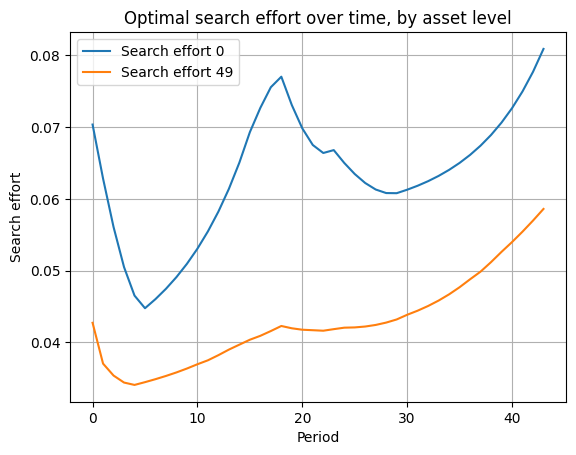

In [94]:
plt.plot(S[0,:-1], label="Search effort 0")
plt.plot(S[49,:-1], label="Search effort 49")
#plt.plot(S[10,:], label="Search")
plt.xlabel("Period")
plt.ylabel("Search effort")
plt.title("Optimal search effort over time, by asset level")
plt.legend()
plt.grid(True)
plt.show()

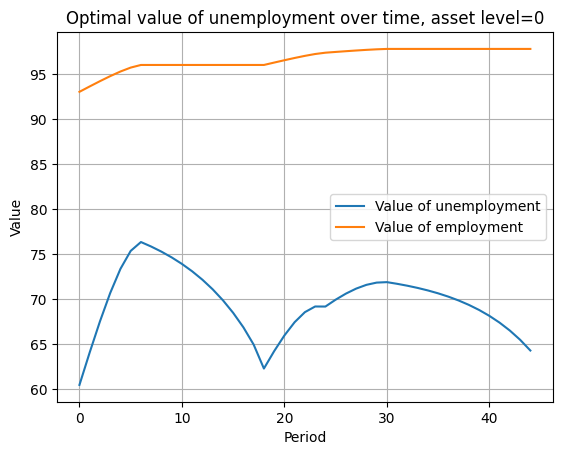

In [95]:
plt.plot(V_unemp[0,:], label="Value of unemployment")
plt.plot(V_emp[0,:], label="Value of employment")
#plt.plot(S[10,:], label="Search")
plt.xlabel("Period")
plt.ylabel("Value")
plt.title("Optimal value of unemployment over time, asset level=0")
plt.legend()
plt.grid(True)
plt.show()

In [96]:
moments = model.simulate_moments(params, institutions_pre, institutions_post, abar, weights)
timevec = np.arange((len(moments))/2)*15 + 15

Optimal consumption of assets solved in 280 iterations, using 0.14314 seconds
Optimal consumption of assets solved in 275 iterations, using 0.15115 seconds
Optimal consumption of assets solved in 280 iterations, using 0.13245 seconds
Optimal consumption of assets solved in 275 iterations, using 0.13569 seconds


In [97]:
# Create target (empirical moments) and covariance matrix
target, cov = model.matchingMoments()

# Create weighting function
W = np.linalg.inv(cov)



In [98]:
# Create SSE, distance measure
SSE = model.sse(params, target, W, institutions_pre, institutions_post, abar, weights)

Optimal consumption of assets solved in 280 iterations, using 0.11273 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09454 seconds
Optimal consumption of assets solved in 280 iterations, using 0.11292 seconds
Optimal consumption of assets solved in 275 iterations, using 0.10881 seconds


In [99]:
print(f'SSE (Goodness of Fit): {SSE}')

SSE (Goodness of Fit): 3730.7149033836513


In [100]:
def split_half(arr):
    mid = len(arr) // 2
    return arr[:mid], arr[mid:]

pre, post = split_half(moments)


emp_pre, emp_post = split_half(target)


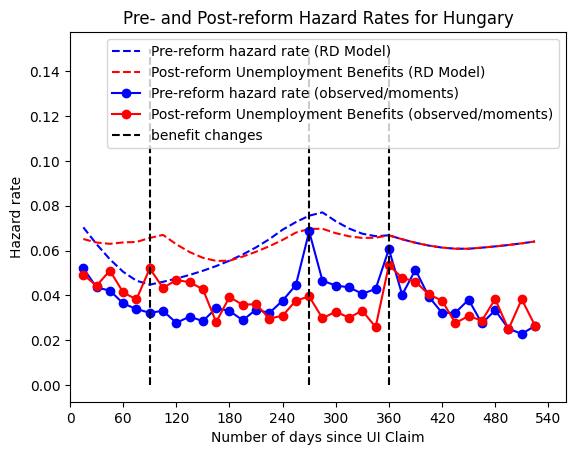

In [101]:
plt.plot(timevec, pre, label='Pre-reform hazard rate (RD Model)', linestyle='dashed', color='blue')
plt.plot(timevec, post, label='Post-reform Unemployment Benefits (RD Model)', linestyle='dashed', color='red')
plt.plot(timevec, emp_pre, label='Pre-reform hazard rate (observed/moments)', marker='o', color='blue')
plt.plot(timevec, emp_post, label='Post-reform Unemployment Benefits (observed/moments)', marker='o', color='red')

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.title('Pre- and Post-reform Hazard Rates for Hungary')
plt.vlines(x=[6*15, 18*15, 24*15], ymin=0, ymax=0.15, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.show()

In [102]:
fixed_params = params

In [103]:
sse1 = model.sse(fixed_params, target, W, institutions_pre, institutions_post, abar, weights)

Optimal consumption of assets solved in 280 iterations, using 0.11195 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09564 seconds
Optimal consumption of assets solved in 280 iterations, using 0.09657 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09507 seconds


In [104]:
params_full = pd.DataFrame(
    data={"value":[0.93, 0.9, 1, 300, 4.9, 6]},
    index=["delta", "gamma", "eta", "k", "lmbda", "N"]
    )

In [105]:
params_full

,value
delta,0.93
gamma,0.90
eta,1.00
k,300.00
lmbda,4.90
N,6.00


In [106]:
smm_object = model.smm(params_full.copy(), target, W, institutions_pre, institutions_post, abar, weights)

In [107]:
params2 = pd.DataFrame(
    data={"value":[0.3],
    "lower_bound" : [0.01],
    "upper_bound" : [2]},
    index=["gamma"],
    )

In [108]:
params2

,value,lower_bound,upper_bound
gamma,0.3,0.01,2


In [109]:
print(f'GMM SSE for gamma=0.3: {smm_object.sse(params2)}')

Optimal consumption of assets solved in 280 iterations, using 0.1018 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09485 seconds
Optimal consumption of assets solved in 280 iterations, using 0.09712 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09364 seconds
GMM SSE for gamma=0.3: 8743.660581029419


In [110]:
res = om.minimize(criterion=smm_object.sse, params=params2, algorithm='scipy_lbfgsb', )

Optimal consumption of assets solved in 280 iterations, using 0.10195 seconds


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/deprecations.py:31: FutureWarning:

To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.



Optimal consumption of assets solved in 275 iterations, using 0.09618 seconds
Optimal consumption of assets solved in 280 iterations, using 0.09725 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09478 seconds
Optimal consumption of assets solved in 280 iterations, using 0.09615 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09375 seconds
Optimal consumption of assets solved in 280 iterations, using 0.09733 seconds
Optimal consumption of assets solved in 275 iterations, using 0.13018 seconds
Optimal consumption of assets solved in 280 iterations, using 0.1817 seconds
Optimal consumption of assets solved in 275 iterations, using 0.17418 seconds
Optimal consumption of assets solved in 280 iterations, using 0.11233 seconds
Optimal consumption of assets solved in 275 iterations, using 0.10815 seconds
Optimal consumption of assets solved in 280 iterations, using 0.13388 seconds
Optimal consumption of assets solved in 275 iterations, using 0.1

In [111]:
print(f'Optimized gamma parameter: {res.params}')
print(f'Objective function(SSE) at optimized gamma (minimum): {res.criterion}')

Optimized gamma parameter:           value  lower_bound  upper_bound
gamma  0.726254         0.01            2
Objective function(SSE) at optimized gamma (minimum): 342.6491432042644


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/optimization/optimize_result.py:77: FutureWarning:

The criterion attribute is deprecated. Use the fun attribute instead.



In [112]:
smm_object.params_full.update(res.params)
print(smm_object.params_full)

            value
delta    0.930000
gamma    0.726254
eta      1.000000
k      300.000000
lmbda    4.900000
N        6.000000


In [113]:
params_rd = pd.DataFrame(
    data={"value":params[:5],
    "lower_bound" : [0.01, 1e-2, 0.01, 1e-5, 0.01],
    "upper_bound" : [0.95, 2, 15, 2000, 15]},
    index=["delta", "gamma", "eta", "k", "lmbda"],
    )

In [114]:
params_rd

,value,lower_bound,upper_bound
delta,0.93,0.01000,0.95
gamma,0.90,0.01000,2.00
eta,1.00,0.01000,15.00
k,300.00,0.00001,2000.00
lmbda,4.90,0.01000,15.00


In [115]:
print(f'SMM SSE for params_rd: {smm_object.sse(params_rd)}')


Optimal consumption of assets solved in 280 iterations, using 0.10764 seconds
Optimal consumption of assets solved in 275 iterations, using 0.10905 seconds
Optimal consumption of assets solved in 280 iterations, using 0.10163 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09759 seconds
SMM SSE for params_rd: 3730.714903383651


In [116]:
res_rd = om.minimize(criterion=smm_object.sse, params=params_rd, algorithm='scipy_lbfgsb', )

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/deprecations.py:31: FutureWarning:

To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.



Optimal consumption of assets solved in 280 iterations, using 0.17953 seconds
Optimal consumption of assets solved in 275 iterations, using 0.11663 seconds
Optimal consumption of assets solved in 280 iterations, using 0.10993 seconds
Optimal consumption of assets solved in 275 iterations, using 0.11803 seconds
Optimal consumption of assets solved in 280 iterations, using 0.15063 seconds
Optimal consumption of assets solved in 275 iterations, using 0.13411 seconds
Optimal consumption of assets solved in 280 iterations, using 0.11699 seconds
Optimal consumption of assets solved in 275 iterations, using 0.13556 seconds
Optimal consumption of assets solved in 280 iterations, using 0.13292 seconds
Optimal consumption of assets solved in 275 iterations, using 0.11171 seconds
Optimal consumption of assets solved in 280 iterations, using 0.10331 seconds
Optimal consumption of assets solved in 275 iterations, using 0.12167 seconds
Optimal consumption of assets solved in 280 iterations, using 0.

In [117]:
print(f'Optimized parameters: {res_rd.params}')
print(f'Objective function(SSE) at optimized parameters: {res_rd.criterion}')

Optimized parameters:             value  lower_bound  upper_bound
delta    0.942211      0.01000         0.95
gamma    0.616462      0.01000         2.00
eta      1.345860      0.01000        15.00
k      290.957735      0.00001      2000.00
lmbda    5.878811      0.01000        15.00
Objective function(SSE) at optimized parameters: 276.6127502137423


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/optimization/optimize_result.py:77: FutureWarning:

The criterion attribute is deprecated. Use the fun attribute instead.



In [118]:
fig = om.criterion_plot(res_rd)
fig

In [128]:
print(res_rd)

Minimize with 5 free parameters terminated unsuccessfully after 165 criterion evaluations, 165 derivative evaluations and 37 iterations.

The value of criterion improved from 3730.7149033836513 to 276.6127502137423.

The scipy_lbfgsb algorithm reported: ABNORMAL: 

Independent of the convergence criteria used by scipy_lbfgsb, the strength of convergence can be assessed by the following criteria:

                             one_step     five_steps 
relative_criterion_change  2.134e-08*    1.511e-07*  
relative_params_change     2.084e-07*    1.434e-06*  
absolute_criterion_change  5.898e-06*    4.175e-05   
absolute_params_change     2.038e-07*    1.403e-06*  

(***: change <= 1e-10, **: change <= 1e-8, *: change <= 1e-5. Change refers to a change between accepted steps. The first column only considers the last step. The second column considers the last five steps.)


In [119]:
res_rd.params

,value,lower_bound,upper_bound
delta,0.942211,0.01000,0.95
gamma,0.616462,0.01000,2.00
eta,1.345860,0.01000,15.00
k,290.957735,0.00001,2000.00
lmbda,5.878811,0.01000,15.00


In [120]:
opt =res_rd.params

In [121]:
#insert params_rd on first 5 columns of params
params_opt = params
params_opt[:5] = res_rd.params['value']
params_opt

array([  0.9422105 ,   0.61646249,   1.34585951, 290.95773509,
         5.87881123,   6.        ])

In [122]:
moments = model.simulate_moments(params_opt, institutions_pre, institutions_post, abar, weights)
opt_pre, opt_post = split_half(moments)


opt_emp_pre, opt_emp_post = split_half(target)




Optimal consumption of assets solved in 341 iterations, using 0.12429 seconds
Optimal consumption of assets solved in 335 iterations, using 0.12405 seconds
Optimal consumption of assets solved in 341 iterations, using 0.11749 seconds
Optimal consumption of assets solved in 335 iterations, using 0.12064 seconds


In [123]:
sse_opt = model.sse(params_opt, target, W, institutions_pre, institutions_post, abar, weights)
print(f'SSE (Goodness of Fit) for optimized parameters: {sse_opt}')

Optimal consumption of assets solved in 341 iterations, using 0.13382 seconds
Optimal consumption of assets solved in 335 iterations, using 0.11816 seconds
Optimal consumption of assets solved in 341 iterations, using 0.12065 seconds
Optimal consumption of assets solved in 335 iterations, using 0.11995 seconds
SSE (Goodness of Fit) for optimized parameters: 276.417631122703


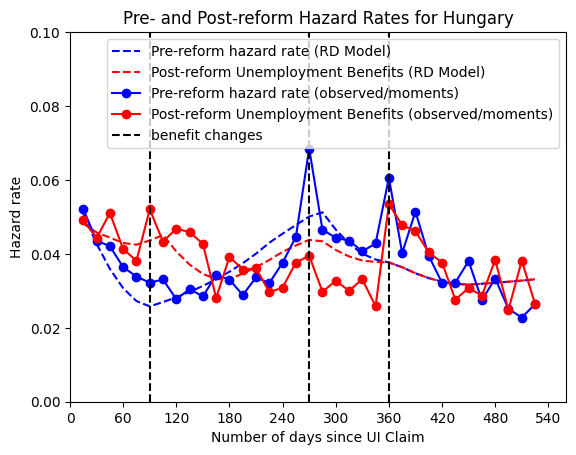

In [127]:
plt.plot(timevec, opt_pre, label='Pre-reform hazard rate (RD Model)', linestyle='dashed', color='blue')
plt.plot(timevec, opt_post, label='Post-reform Unemployment Benefits (RD Model)', linestyle='dashed', color='red')
plt.plot(timevec, opt_emp_pre, label='Pre-reform hazard rate (observed/moments)', marker='o', color='blue')
plt.plot(timevec, opt_emp_post, label='Post-reform Unemployment Benefits (observed/moments)', marker='o', color='red')

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.ylim(0, 0.1) # set x-axis limits to first and last element in timevec
plt.title('Pre- and Post-reform Hazard Rates for Hungary')
plt.vlines(x=[6*15, 18*15, 24*15], ymin=0, ymax=0.15, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.show()

In [129]:
asset_indices = [0, 5, 10, 25, 50, 75, 99]

for i in asset_indices:
    plt.plot(
        timevec,
        S_pre[i, :35],
        label=f"A = {a_grid[i]:.0f}"
    )

plt.xlabel("Days since UI claim")
plt.ylabel("Search effort")
plt.legend()
plt.show()

NameError: name 'S_pre' is not defined